# F1 Driver Helmet Classifier
A deep learning model that identifies F1 drivers from helmet designs using transfer learning on VGG16.
- Dataset: Custom scraped from Racing Helmets Garage
- Classes: 10 F1 drivers from the 2026 grid
- Accuracy: 61% validation accuracy

## 1. Setup & Imports

In [26]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Collection
Scraping helmet images from racinghelmetsgarage.blogspot.com for each driver

In [27]:
!pip install requests beautifulsoup4

import requests
from bs4 import BeautifulSoup
import os
import time

base_dir = "/content/drive/My Drive/f1_helmets"

drivers = {
    #"lewis_hamilton": "Lewis%20Hamilton",
    #"max_verstappen": "Max%20Verstappen",
    #"charles_leclerc": "Charles%20Leclerc",
    #"lando_norris": "Lando%20Norris",
    #"oscar_piastri": "Oscar%20Piastri",
    #"george_russell": "George%20Russell",
    #"fernando_alonso": "Fernando%20Alonso",
    #"carlos_sainz": "Carlos%20Sainz",
    #"alex_albon": "Alex%20Albon",
    #"lance_stroll": "Lance%20Stroll",
    #"pierre_gasly": "Pierre%20Gasly",
    #"esteban_ocon": "Esteban%20Ocon",
    #"nico_hulkenberg": "Nico%20Hulkenberg",
    #"valtteri_bottas": "Valtteri%20Bottas",
    #"sergio_perez": "Sergio%20Perez",
    #"kimi_antonelli": "Kimi%20Antonelli",
    #"oliver_bearman": "Oliver%20Bearman",
    #"liam_lawson": "Liam%20Lawson",
    #"franco_colapinto": "Franco%20Colapinto",
    #"gabriel_bortoleto": "Gabriel%20Bortoleto",
    #"isack_hadjar": "Isack%20Hadjar",
    #"arvid_lindblad": "Arvid%20Lindblad",
}


headers = {"User-Agent": "Mozilla/5.0"}

def get_all_pages(driver_label):
    """Get all page URLs for a driver label"""
    urls = []
    url = f"https://racinghelmetsgarage.blogspot.com/search/label/{driver_label}"
    while url:
        urls.append(url)
        res = requests.get(url, headers=headers)
        soup = BeautifulSoup(res.text, "html.parser")
        # find "older posts" link
        older = soup.find("a", id="Blog1_blog-pager-older-link")
        url = older["href"] if older else None
        time.sleep(1)
    return urls

def scrape_driver(driver_key, driver_label):
    folder = f"{base_dir}/{driver_key}"
    os.makedirs(folder, exist_ok=True)
    count = 0

    pages = get_all_pages(driver_label)
    print(f"{driver_key}: {len(pages)} pages found")

    for page_url in pages:
        res = requests.get(page_url, headers=headers)
        soup = BeautifulSoup(res.text, "html.parser")

        # Images are linked inside <a> tags pointing to full-res blogger CDN
        for a_tag in soup.find_all("a", href=True):
            href = a_tag["href"]
            # Blogger full-res images contain /s followed by large number
            if "blogger.googleusercontent.com" in href and "/s" in href:
                # Force highest resolution
                img_url = href.split("/s")[0] + "/s2048/" + href.split("/")[-1]
                try:
                    img_data = requests.get(img_url, headers=headers, timeout=10).content
                    if len(img_data) > 10000:  # skip tiny/broken images
                        with open(f"{folder}/{driver_key}_{count}.jpg", "wb") as f:
                            f.write(img_data)
                        count += 1
                        time.sleep(0.3)
                except:
                    continue

        time.sleep(1)

    print(f"✓ {driver_key}: {count} images saved")

# Run
for driver_key, driver_label in drivers.items():
    scrape_driver(driver_key, driver_label)

Counting all the data retrieved

In [28]:
import os

base_dir = "/content/drive/My Drive/f1_helmets"

for driver in os.listdir(base_dir):
    folder = f"{base_dir}/{driver}"
    count = len(os.listdir(folder))
    print(f"{driver}: {count} images")

lewis_hamilton: 313 images
max_verstappen: 268 images
charles_leclerc: 418 images
lando_norris: 468 images
oscar_piastri: 179 images
george_russell: 267 images
fernando_alonso: 221 images
carlos_sainz: 206 images
lance_stroll: 0 images
pierre_gasly: 264 images
esteban_ocon: 225 images


## 3. Data Loading & Preprocessing
Loading images, resizing to 224x224, normalizing pixel values, train/val split

Cleaning the Dataset


In [30]:
from PIL import Image
import hashlib
import os

def clean(folder):
    seen, removed = set(), 0
    for f in os.listdir(folder):
        p = f"{folder}/{f}"
        try:
            img = Image.open(p)
            if img.size[0] < 150 or img.size[1] < 150:
                os.remove(p); removed += 1; continue
            h = hashlib.md5(open(p,'rb').read()).hexdigest()
            if h in seen:
                os.remove(p); removed += 1
            else:
                seen.add(h)
        except:
            os.remove(p); removed += 1
    print(f"{folder.split('/')[-1]}: {len(os.listdir(folder))} kept, {removed} removed")

for driver in os.listdir(base_dir):
    clean(f"{base_dir}/{driver}")

lewis_hamilton: 313 kept, 0 removed
max_verstappen: 268 kept, 0 removed
charles_leclerc: 418 kept, 0 removed
lando_norris: 468 kept, 0 removed
oscar_piastri: 179 kept, 0 removed
george_russell: 267 kept, 0 removed
fernando_alonso: 221 kept, 0 removed
carlos_sainz: 206 kept, 0 removed
pierre_gasly: 264 kept, 0 removed
esteban_ocon: 225 kept, 0 removed


Loading the dataset

In [31]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split

base_dir = "/content/drive/My Drive/f1_helmets"
IMG_SIZE = 224

images = []
labels = []
class_names = sorted(os.listdir(base_dir))
for label_idx, driver in enumerate(class_names):
    folder = f"{base_dir}/{driver}"
    for fname in os.listdir(folder):
        fpath = f"{folder}/{fname}"
        try:
            img = cv2.imread(fpath)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label_idx)
        except:
            continue
    print(f"{driver}: loaded")

images = np.array(images, dtype="float32") / 255.0  # normalize
labels = np.array(labels)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")


carlos_sainz: loaded
charles_leclerc: loaded
esteban_ocon: loaded
fernando_alonso: loaded
george_russell: loaded
lando_norris: loaded
lewis_hamilton: loaded
max_verstappen: loaded
oscar_piastri: loaded
pierre_gasly: loaded
Train: (2263, 224, 224, 3), Val: (566, 224, 224, 3)


## 4. Model Architecture
VGG16 pretrained on ImageNet with custom classification head

In [32]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

NUM_CLASSES = len(class_names)

# Load VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Build on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,627,210 (105.39 MB)

 Trainable params: 12,912,522 (49.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5. Training
Early stopping monitors val_accuracy with patience of 5 epochs

In [33]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,         # stops if no improvement for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.1582 - loss: 2.9551 - val_accuracy: 0.2792 - val_loss: 2.0890
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.2399 - loss: 2.1392 - val_accuracy: 0.3057 - val_loss: 2.0184
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.2930 - loss: 1.9856 - val_accuracy: 0.3887 - val_loss: 1.8271
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - accuracy: 0.3464 - loss: 1.8760 - val_accuracy: 0.4028 - val_loss: 1.8087
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.3522 - loss: 1.8050 - val_accuracy: 0.4541 - val_loss: 1.7304
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 221ms/step - accuracy: 0.3791 - loss: 1.7300 - val_accuracy: 0.4558 - val_loss: 1.6559
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.4057 - loss: 1.6445 - val_accuracy: 0.4982 - val_loss: 1.5828
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.4308 - loss: 1.5655 - val_accu

## 6. Evaluation
Classification report and confusion matrix

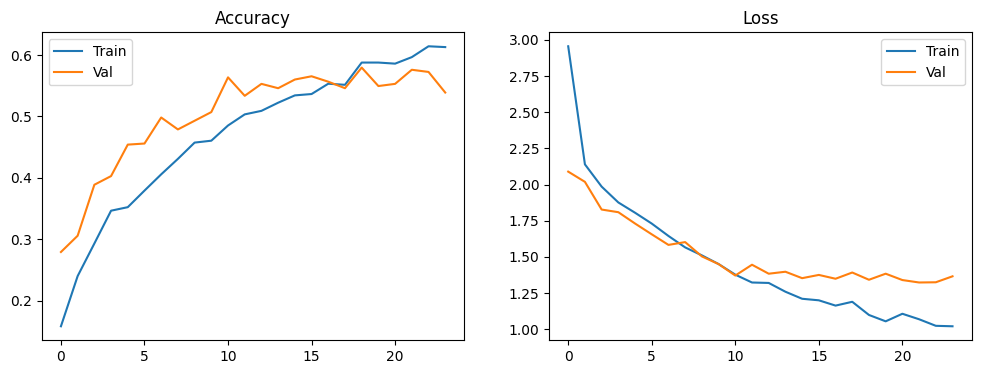

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend()
plt.show()

In [8]:
model.save("/content/drive/My Drive/f1_helmet_classifier.h5")
print("Model saved.")

Model saved.


Classification Report


In [35]:
from sklearn.metrics import classification_report

# Rebuild class_names from only valid drivers
class_names = sorted([
    driver for driver in os.listdir(base_dir)
    if len(os.listdir(f"{base_dir}/{driver}")) >= 20
])

preds = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val, preds, target_names=class_names))

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step
                 precision    recall  f1-score   support

   carlos_sainz       0.33      0.07      0.12        41
charles_leclerc       0.59      0.73      0.65        84
   esteban_ocon       0.29      0.33      0.31        45
fernando_alonso       0.55      0.52      0.53        44
 george_russell       0.68      0.64      0.66        53
   lando_norris       0.68      0.68      0.68        94
 lewis_hamilton       0.38      0.57      0.46        63
 max_verstappen       0.84      0.81      0.83        53
  oscar_piastri       0.71      0.47      0.57        36
   pierre_gasly       0.70      0.60      0.65        53

       accuracy                           0.58       566
      macro avg       0.57      0.54      0.55       566
   weighted avg       0.59      0.58      0.57       566



Confusion Matrix


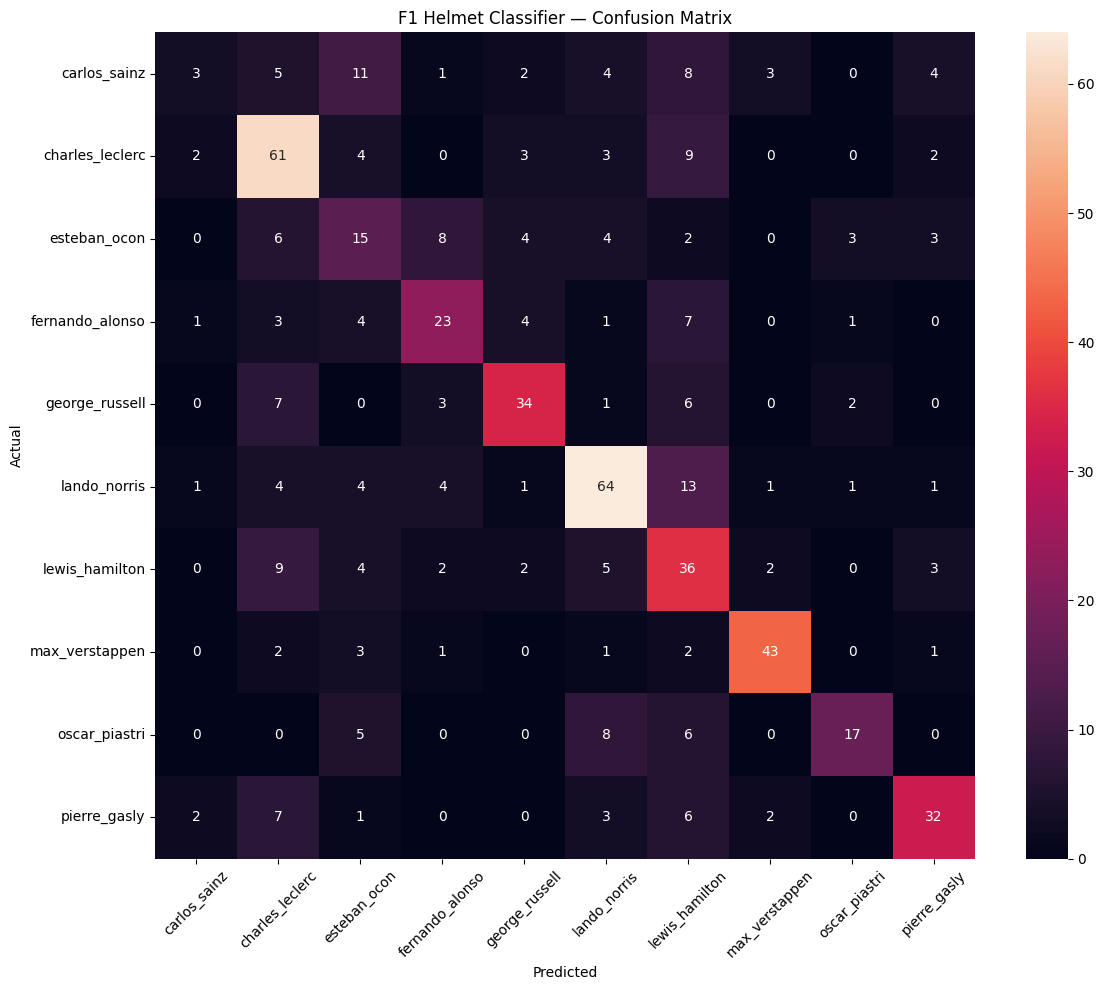

In [36]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('F1 Helmet Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/confusion_matrix.png")
plt.show()

In [12]:
model.save("/content/drive/My Drive/f1_helmet_classifier.keras")
print("Done.")

Done.


## 7. Inference
Predict driver from a single helmet image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


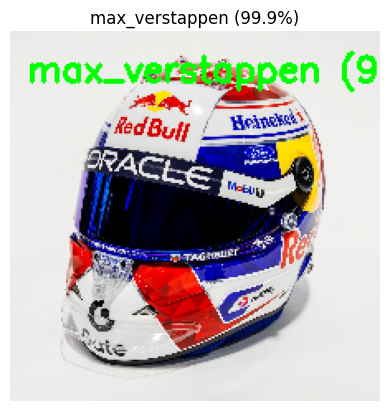

In [41]:
def predict_helmet(img_path, model, class_names):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    preds = model.predict(img_input)
    pred_idx = np.argmax(preds)
    confidence = preds[0][pred_idx] * 100

    label = f"{class_names[pred_idx]} ({confidence:.1f}%)"
    img_display = cv2.putText(img_resized.copy(), label, (10, 30),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(label)
    plt.show()

class_names = sorted([d for d in os.listdir(base_dir) if len(os.listdir(f"{base_dir}/{d}")) >= 30])
predict_helmet("/content/max_verstappen_3.jpg", model, class_names)

